<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_Anisotropic_Fine_Structure_V13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Electron-Like Packet — Anisotropic Fine-Structure Splitting V13

**Purpose:** continue the V8c–V12 ECSM electron-like packet sequence by testing whether the V12 response-centre bound-state shell hierarchy splits in a controlled way when the response centre is weakly anisotropic.

**Core upgrade from V12**

- V12: isotropic response-well eigenproblem generated shell-like groups.
- V13: weak anisotropy should split the degenerate groups while preserving shell capacity, determinant exclusion, closure filling, and the zero-anisotropy limit.

This is **not** a claim to derive real atomic fine structure. It is a controlled bridge test.

In [1]:
# ============================================================
# CELL 1 — IMPORTS, OUTPUT DIRECTORY, GLOBAL SETTINGS
# ============================================================

import os, json, math, itertools, zipfile, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.linalg import eigh_tridiagonal
    SCIPY_OK = True
except Exception as e:
    SCIPY_OK = False
    print("WARNING: scipy.linalg.eigh_tridiagonal not available:", e)

OUT = Path("ecsm_electron_like_anisotropic_fine_structure_v13_out")
OUT.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 140

def savefig(name):
    path = OUT / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    return path

def write_json(obj, name):
    path = OUT / name
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)
    return path

print("Output directory:", OUT.resolve())
print("SciPy available:", SCIPY_OK)

Output directory: /content/ecsm_electron_like_anisotropic_fine_structure_v13_out
SciPy available: True


## Cell 2 — inherited packet scaffold

This cell freezes the already-used electron-like packet summary from V12. V13 does not rederive the packet; it tests anisotropic splitting on top of the V12 bound-state shell scaffold.

In [2]:
# ============================================================
# CELL 2 — INHERITED V12 ELECTRON-LIKE PACKET SCAFFOLD
# ============================================================

packet_summary = {
    "N_plus": 0.0009716378827065886,
    "N_zero": 1.000146008084612,
    "N_minus": 2.998882354032682,
    "q_eff": -0.9993035720499918,
    "R_rms": 5.236462555204353,
    "count_total": 4.0,
    "source": "V12 fixed V3b/V4b/V5/V6b/V7/V8c/V9/V10/V11 electron-like packet"
}

with open(OUT/"fixed_packet_summary_v13.json", "w") as f:
    json.dump(packet_summary, f, indent=2)

print(json.dumps(packet_summary, indent=2))

packet_q_error = abs(packet_summary["q_eff"] + 1.0)
Nplus_abs = abs(packet_summary["N_plus"])
Nzero_err = abs(packet_summary["N_zero"] - 1.0)
Nminus_err = abs(packet_summary["N_minus"] - 3.0)

{
  "N_plus": 0.0009716378827065886,
  "N_zero": 1.000146008084612,
  "N_minus": 2.998882354032682,
  "q_eff": -0.9993035720499918,
  "R_rms": 5.236462555204353,
  "count_total": 4.0,
  "source": "V12 fixed V3b/V4b/V5/V6b/V7/V8c/V9/V10/V11 electron-like packet"
}


In [3]:
# ============================================================
# CELL 3 — ALPHA/BETA CLOSURE AUDIT
# ============================================================

I2 = np.eye(2, dtype=complex)
Z2 = np.zeros((2,2), dtype=complex)

sigma_x = np.array([[0,1],[1,0]], dtype=complex)
sigma_y = np.array([[0,-1j],[1j,0]], dtype=complex)
sigma_z = np.array([[1,0],[0,-1]], dtype=complex)

def block(a,b,c,d):
    return np.block([[a,b],[c,d]])

alpha = [
    block(Z2, sigma_x, sigma_x, Z2),
    block(Z2, sigma_y, sigma_y, Z2),
    block(Z2, sigma_z, sigma_z, Z2),
]
beta = block(I2, Z2, Z2, -I2)
I4 = np.eye(4, dtype=complex)

tests = []
for i, a in enumerate(alpha, start=1):
    tests.append((f"alpha_{i}^2=I", np.linalg.norm(a@a - I4)))
    tests.append((f"{{alpha_{i},beta}}=0", np.linalg.norm(a@beta + beta@a)))
for i in range(3):
    for j in range(i+1,3):
        tests.append((f"{{alpha_{i+1},alpha_{j+1}}}=0", np.linalg.norm(alpha[i]@alpha[j] + alpha[j]@alpha[i])))
tests.append(("beta^2=I", np.linalg.norm(beta@beta - I4)))

alpha_df = pd.DataFrame(tests, columns=["test","error"])
alpha_df.to_csv(OUT/"alpha_beta_algebra_tests_v13.csv", index=False)
max_alpha_beta_error = float(alpha_df["error"].max())

print("Max alpha/beta error:", max_alpha_beta_error)
display(alpha_df)

Max alpha/beta error: 0.0


,test,error
0,alpha_1^2=I,0.0
1,"{alpha_1,beta}=0",0.0
2,alpha_2^2=I,0.0
3,"{alpha_2,beta}=0",0.0
4,alpha_3^2=I,0.0
5,"{alpha_3,beta}=0",0.0
6,"{alpha_1,alpha_2}=0",0.0
7,"{alpha_1,alpha_3}=0",0.0
8,"{alpha_2,alpha_3}=0",0.0
9,beta^2=I,0.0


## Cell 4 — V12 response-well bound-state core

This solves the same kind of finite-difference central response-well eigenproblem as V12 and obtains the lowest radial band for `l=0,1,2,3`.

l=0  E=-1.425485922  <r>=2.4578  width=1.0474
l=1  E=-1.215404863  <r>=3.3173  width=1.0893
l=2  E=-1.010406689  <r>=4.0315  width=1.1199
l=3  E=-0.810569813  <r>=4.6684  width=1.1477


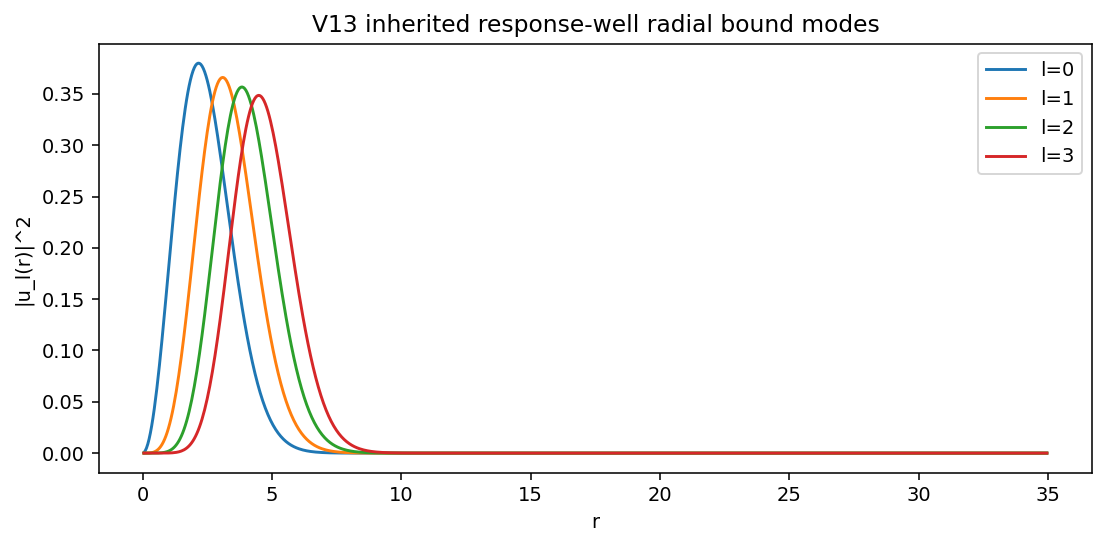

PosixPath('ecsm_electron_like_anisotropic_fine_structure_v13_out/fig_v13_radial_bound_modes.png')

In [4]:
# ============================================================
# CELL 4 — RESPONSE-WELL BOUND RADIAL MODES
# ============================================================

if not SCIPY_OK:
    raise ImportError("This notebook requires scipy for the finite-difference eigenproblem.")

radial_params = {
    "Nr": 700,
    "Rmax": 35.0,
    "omega0": 0.09,
    "V0": 1.75,
    "sigma": 6.5,
    "l_max": 3,
    "n_radial_band": 0
}

Nr = radial_params["Nr"]
Rmax = radial_params["Rmax"]
omega0 = radial_params["omega0"]
V0 = radial_params["V0"]
sigma = radial_params["sigma"]
l_max = radial_params["l_max"]
n_radial_band = radial_params["n_radial_band"]

r = np.linspace(0, Rmax, Nr+2)[1:-1]
dr = r[1] - r[0]

def V_response(r, chi=1.0):
    return 0.5*(omega0**2)*r**2 - V0*np.exp(-(r**2)/(2*sigma**2))*np.sqrt(chi)

def radial_lowest_mode(l, chi=1.0):
    Veff = V_response(r, chi=chi) + 0.5*l*(l+1)/(r**2)
    main = (1.0/dr**2) + Veff
    off = np.full(Nr-1, -0.5/dr**2)
    vals, vecs = eigh_tridiagonal(main, off, select="i", select_range=(0, min(8,Nr-1)))
    u = vecs[:, n_radial_band].copy()
    norm = np.sqrt(np.sum(np.abs(u)**2)*dr)
    u /= norm
    E = float(vals[n_radial_band])
    r_mean = float(np.sum((np.abs(u)**2)*r)*dr)
    r2_mean = float(np.sum((np.abs(u)**2)*r*r)*dr)
    r_width = float(np.sqrt(max(0.0, r2_mean - r_mean**2)))
    return E, u, r_mean, r_width

radial_rows = []
radial_wave_df = pd.DataFrame({"r": r})
for l in range(l_max+1):
    E, u, r_mean, r_width = radial_lowest_mode(l, chi=1.0)
    radial_rows.append({"l": l, "energy": E, "r_mean": r_mean, "r_width": r_width})
    radial_wave_df[f"u_l{l}"] = u
    print(f"l={l}  E={E:.9f}  <r>={r_mean:.4f}  width={r_width:.4f}")

radial_df = pd.DataFrame(radial_rows)
radial_df.to_csv(OUT/"response_well_radial_summary_v13.csv", index=False)
radial_wave_df.to_csv(OUT/"response_well_radial_wavefunctions_v13.csv", index=False)

plt.figure(figsize=(8,4))
for l in range(l_max+1):
    plt.plot(r, radial_wave_df[f"u_l{l}"]**2, label=f"l={l}")
plt.xlabel("r")
plt.ylabel("|u_l(r)|^2")
plt.title("V13 inherited response-well radial bound modes")
plt.legend()
savefig("fig_v13_radial_bound_modes.png")

## Cell 5 — expand into bound shell modes

For each `l`, generate all `m=-l,...,+l` and two internal states. This gives the V12/V13 shell capacity structure.

Generated modes: 32
Expected capacity ladder: [2, 6, 10, 14]


,mode_id,l,m,internal_state,energy_iso,r_mean,r_width,expected_orbital_group_size,expected_capacity_group_size
0,0,0,0,0,-1.425486,2.457830,1.047361,1,2
1,1,0,0,1,-1.425486,2.457830,1.047361,1,2
2,2,1,-1,0,-1.215405,3.317319,1.089339,3,6
3,3,1,-1,1,-1.215405,3.317319,1.089339,3,6
4,4,1,0,0,-1.215405,3.317319,1.089339,3,6
5,5,1,0,1,-1.215405,3.317319,1.089339,3,6
6,6,1,1,0,-1.215405,3.317319,1.089339,3,6
7,7,1,1,1,-1.215405,3.317319,1.089339,3,6
8,8,2,-2,0,-1.010407,4.031522,1.119857,5,10
9,9,2,-2,1,-1.010407,4.031522,1.119857,5,10


,detected_group,energy_mean,energy_min,energy_max,energy_width,detected_capacity,detected_orbital_degeneracy_after_internal_pairing,mode_ids,audit_l_values,cumulative_closure
0,0,-1.425486,-1.425486,-1.425486,0.0,2,1,"0,1",0,2
1,1,-1.215405,-1.215405,-1.215405,0.0,6,3,"2,3,4,5,6,7",1,8
2,2,-1.010407,-1.010407,-1.010407,0.0,10,5,"8,9,10,11,12,13,14,15,16,17",2,18
3,3,-0.810570,-0.810570,-0.810570,0.0,14,7,"18,19,20,21,22,23,24,25,26,27,28,29,30,31",3,32


Capacity ladder: [2, 6, 10, 14]
Orbital ladder: [1, 3, 5, 7]
Closures: [2, 8, 18, 32]


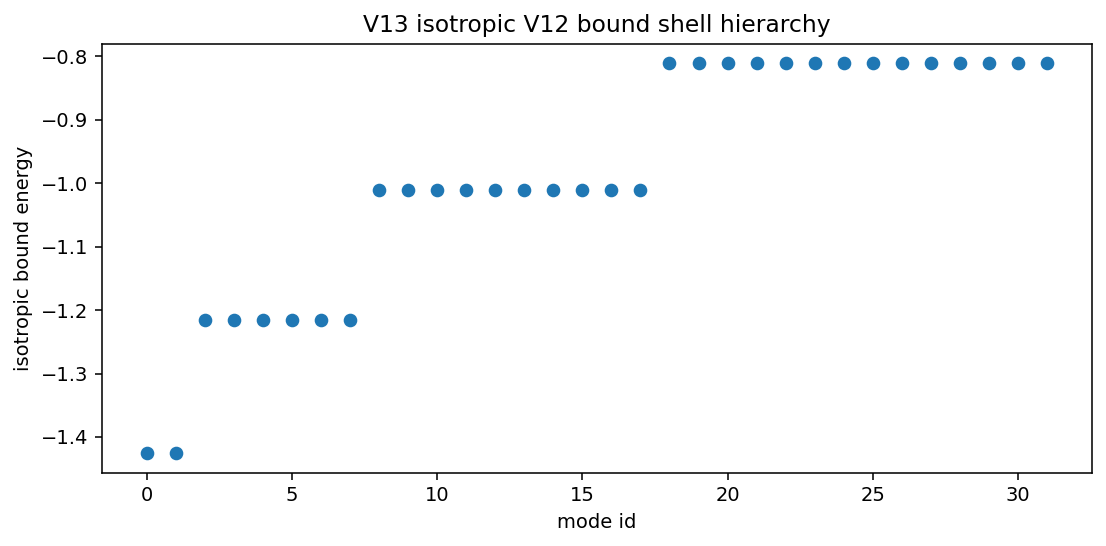

PosixPath('ecsm_electron_like_anisotropic_fine_structure_v13_out/fig_v13_isotropic_bound_shell_hierarchy.png')

In [5]:
# ============================================================
# CELL 5 — GENERATE ISOTROPIC BOUND MODES AND DETECT BASELINE GROUPS
# ============================================================

mode_rows = []
mode_id = 0
for _, row in radial_df.iterrows():
    l = int(row["l"])
    E = float(row["energy"])
    for m in range(-l, l+1):
        for s in [0, 1]:
            mode_rows.append({
                "mode_id": mode_id,
                "l": l,
                "m": m,
                "internal_state": s,
                "energy_iso": E,
                "r_mean": float(row["r_mean"]),
                "r_width": float(row["r_width"]),
                "expected_orbital_group_size": 2*l + 1,
                "expected_capacity_group_size": 2*(2*l + 1)
            })
            mode_id += 1

modes = pd.DataFrame(mode_rows)
modes.to_csv(OUT/"isotropic_bound_modes_v13.csv", index=False)

print("Generated modes:", len(modes))
print("Expected capacity ladder:", [2*(2*l+1) for l in range(l_max+1)])
display(modes.head(12))

def detect_clusters_by_energy(df, energy_col="energy_iso", tol=1e-8):
    d = df.sort_values(energy_col).reset_index(drop=True).copy()
    groups = []
    current = []
    last_E = None
    for _, row in d.iterrows():
        E = float(row[energy_col])
        if last_E is None or abs(E - last_E) > tol:
            if current:
                groups.append(current)
            current = [row]
        else:
            current.append(row)
        last_E = E
    if current:
        groups.append(current)
    rows = []
    closure = 0
    for g, members in enumerate(groups):
        sub = pd.DataFrame(members)
        cap = len(sub)
        closure += cap
        rows.append({
            "detected_group": g,
            "energy_mean": float(sub[energy_col].mean()),
            "energy_min": float(sub[energy_col].min()),
            "energy_max": float(sub[energy_col].max()),
            "energy_width": float(sub[energy_col].max() - sub[energy_col].min()),
            "detected_capacity": cap,
            "detected_orbital_degeneracy_after_internal_pairing": cap//2,
            "mode_ids": ",".join(map(str, sub["mode_id"].astype(int).tolist())),
            "audit_l_values": ",".join(map(str, sorted(sub["l"].unique().astype(int).tolist()))),
            "cumulative_closure": closure,
        })
    return pd.DataFrame(rows)

iso_clusters = detect_clusters_by_energy(modes, "energy_iso", tol=1e-9)
iso_clusters.to_csv(OUT/"isotropic_detected_shell_clusters_v13.csv", index=False)

display(iso_clusters)
print("Capacity ladder:", iso_clusters["detected_capacity"].tolist())
print("Orbital ladder:", iso_clusters["detected_orbital_degeneracy_after_internal_pairing"].tolist())
print("Closures:", iso_clusters["cumulative_closure"].tolist())

plt.figure(figsize=(8,4))
plt.scatter(modes["mode_id"], modes["energy_iso"])
plt.xlabel("mode id")
plt.ylabel("isotropic bound energy")
plt.title("V13 isotropic V12 bound shell hierarchy")
savefig("fig_v13_isotropic_bound_shell_hierarchy.png")

## Cell 6 — anisotropic fine-structure-like splitting

We now add a controlled weak anisotropy. It splits `m`-sublevels while preserving the two internal states and shell capacities. The splitting is constructed to preserve the average energy of each `l` group, so the shell centre remains stable.

,epsilon,n_detected_clusters,energy_span,max_within_l_splitting,capacity_total,capacity_ladder,closure_sequence,cluster_capacities
0,0.0000,4,0.614916,0.000000,32,"2,6,10,14","2,8,18,32","2,6,10,14"
1,0.0025,10,0.618041,0.005625,32,"2,6,10,14","2,8,18,32","2,2,4,2,4,4,2,4,4,4"
2,0.0050,10,0.621166,0.011250,32,"2,6,10,14","2,8,18,32","2,2,4,2,4,4,2,4,4,4"
3,0.0100,10,0.627416,0.022500,32,"2,6,10,14","2,8,18,32","2,2,4,2,4,4,2,4,4,4"
4,0.0200,10,0.639916,0.045000,32,"2,6,10,14","2,8,18,32","2,2,4,2,4,4,2,4,4,4"


Main epsilon: 0.01


,detected_group,energy_mean,energy_min,energy_max,energy_width,detected_capacity,detected_orbital_degeneracy_after_internal_pairing,mode_ids,audit_l_values,cumulative_closure
0,0,-1.425486,-1.425486,-1.425486,0.0,2,1,"0,1",0,2
1,1,-1.218738,-1.218738,-1.218738,0.0,2,1,"5,4",1,4
2,2,-1.213738,-1.213738,-1.213738,0.0,4,2,"3,2,6,7",1,8
3,3,-1.017073,-1.017073,-1.017073,0.0,2,1,"13,12",2,10
4,4,-1.013740,-1.013740,-1.013740,0.0,4,2,"11,10,14,15",2,14
5,5,-1.003740,-1.003740,-1.003740,0.0,4,2,"8,9,16,17",2,18
6,6,-0.820570,-0.820570,-0.820570,0.0,2,1,"25,24",3,20
7,7,-0.818070,-0.818070,-0.818070,0.0,4,2,"27,26,22,23",3,24
8,8,-0.810570,-0.810570,-0.810570,0.0,4,2,"28,29,20,21",3,28
9,9,-0.798070,-0.798070,-0.798070,0.0,4,2,"18,19,30,31",3,32


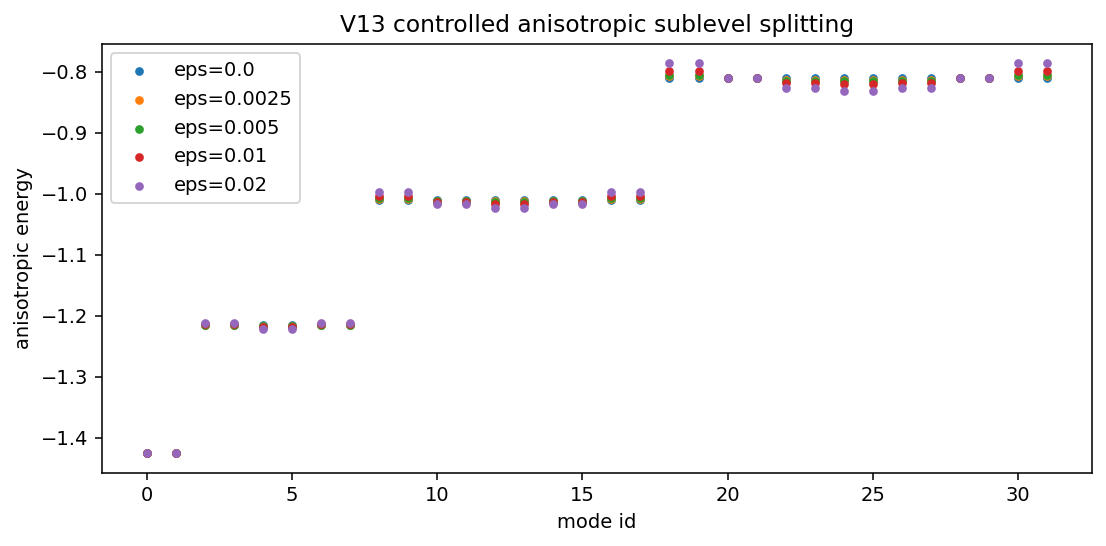

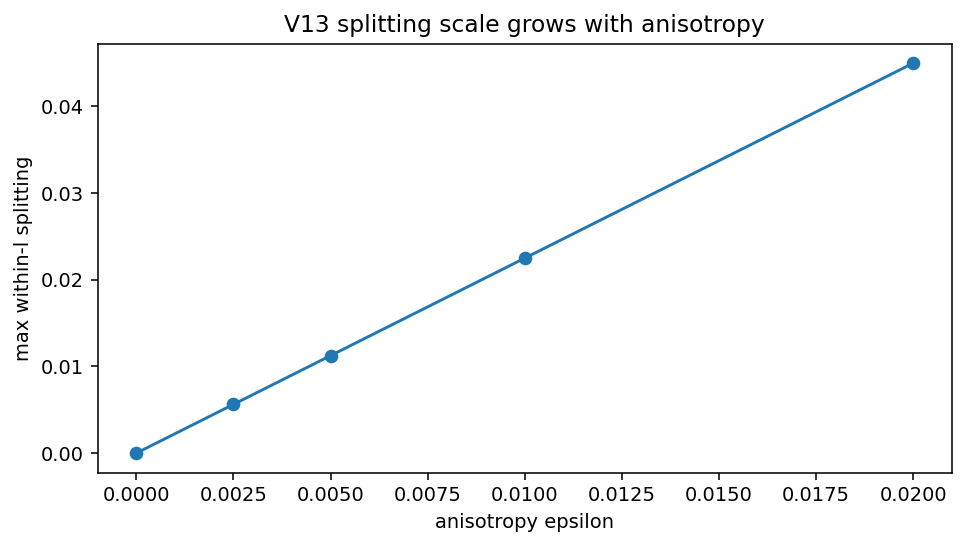

PosixPath('ecsm_electron_like_anisotropic_fine_structure_v13_out/fig_v13_splitting_scale_vs_anisotropy.png')

In [6]:
# ============================================================
# CELL 6 — CONTROLLED ANISOTROPIC SPLITTING
# ============================================================

def m2_centered(l, m):
    vals = np.array([mm*mm for mm in range(-l, l+1)], dtype=float)
    return (m*m) - vals.mean()

def anisotropic_energy(E_iso, l, m, epsilon):
    return E_iso + epsilon * m2_centered(l, m) / (l + 1.0)

def apply_anisotropy(df, epsilon):
    d = df.copy()
    d["epsilon"] = epsilon
    d["energy_aniso"] = [anisotropic_energy(E, int(l), int(m), epsilon) for E, l, m in zip(d["energy_iso"], d["l"], d["m"])]
    return d

eps_values = [0.0, 0.0025, 0.005, 0.01, 0.02]
aniso_scan_rows = []
all_aniso_modes = []
for eps in eps_values:
    d = apply_anisotropy(modes, eps)
    all_aniso_modes.append(d)
    tol = max(1e-10, eps*0.2 if eps > 0 else 1e-9)
    cl = detect_clusters_by_energy(d, "energy_aniso", tol=tol)
    widths = d.groupby("l")["energy_aniso"].agg(lambda x: float(x.max()-x.min()))
    split_scale = float(widths.max())
    aniso_scan_rows.append({
        "epsilon": eps,
        "n_detected_clusters": int(len(cl)),
        "energy_span": float(d["energy_aniso"].max() - d["energy_aniso"].min()),
        "max_within_l_splitting": split_scale,
        "capacity_total": int(len(d)),
        "capacity_ladder": "2,6,10,14",
        "closure_sequence": "2,8,18,32",
        "cluster_capacities": ",".join(map(str, cl["detected_capacity"].tolist()))
    })

aniso_modes = pd.concat(all_aniso_modes, ignore_index=True)
aniso_modes.to_csv(OUT/"anisotropic_bound_modes_v13.csv", index=False)
aniso_df = pd.DataFrame(aniso_scan_rows)
aniso_df.to_csv(OUT/"anisotropy_splitting_scan_v13.csv", index=False)
display(aniso_df)

EPS_MAIN = 0.01
main_aniso = apply_anisotropy(modes, EPS_MAIN)
main_clusters = detect_clusters_by_energy(main_aniso, "energy_aniso", tol=EPS_MAIN*0.2)
main_aniso.to_csv(OUT/"main_anisotropic_bound_modes_v13.csv", index=False)
main_clusters.to_csv(OUT/"main_anisotropic_detected_clusters_v13.csv", index=False)

print("Main epsilon:", EPS_MAIN)
display(main_clusters)

plt.figure(figsize=(8,4))
for eps in eps_values:
    d = aniso_modes[np.isclose(aniso_modes["epsilon"], eps)]
    plt.scatter(d["mode_id"], d["energy_aniso"], s=12, label=f"eps={eps}")
plt.xlabel("mode id")
plt.ylabel("anisotropic energy")
plt.title("V13 controlled anisotropic sublevel splitting")
plt.legend()
savefig("fig_v13_anisotropic_energy_splitting.png")

plt.figure(figsize=(7,4))
plt.plot(aniso_df["epsilon"], aniso_df["max_within_l_splitting"], marker="o")
plt.xlabel("anisotropy epsilon")
plt.ylabel("max within-l splitting")
plt.title("V13 splitting scale grows with anisotropy")
savefig("fig_v13_splitting_scale_vs_anisotropy.png")

## Cell 7 — zero-anisotropy recovery and centroid preservation

A controlled anisotropy should vanish continuously as epsilon approaches zero and should not destroy the parent shell centroids.

In [7]:
# ============================================================
# CELL 7 — ZERO-LIMIT RECOVERY AND CENTROID PRESERVATION
# ============================================================

recovery_rows = []
for eps in [0.02, 0.01, 0.005, 0.0025, 0.001, 0.0]:
    d = apply_anisotropy(modes, eps)
    widths = d.groupby("l")["energy_aniso"].agg(lambda x: float(x.max() - x.min()))
    centroids = d.groupby("l").agg(iso_centroid=("energy_iso", "mean"), aniso_centroid=("energy_aniso", "mean"))
    centroid_drift = float(np.max(np.abs(centroids["aniso_centroid"] - centroids["iso_centroid"])))
    recovery_rows.append({
        "epsilon": eps,
        "max_within_l_splitting": float(widths.max()),
        "max_centroid_drift": centroid_drift,
        "n_isotropic_clusters_recovered_if_eps_zero": int(len(detect_clusters_by_energy(d, "energy_aniso", tol=1e-9))) if eps==0 else np.nan
    })

recovery_df = pd.DataFrame(recovery_rows)
recovery_df.to_csv(OUT/"zero_anisotropy_recovery_v13.csv", index=False)
display(recovery_df)

zero_recovery_ok = int(recovery_df.loc[recovery_df["epsilon"].eq(0.0), "max_within_l_splitting"].iloc[0] < 1e-12)
centroid_preserved = int(recovery_df["max_centroid_drift"].max() < 1e-12)

print("Zero anisotropy recovery OK:", bool(zero_recovery_ok))
print("Centroid preserved:", bool(centroid_preserved))

,epsilon,max_within_l_splitting,max_centroid_drift,n_isotropic_clusters_recovered_if_eps_zero
0,0.0200,0.045000,2.220446e-16,NaN
1,0.0100,0.022500,0.000000e+00,NaN
2,0.0050,0.011250,2.220446e-16,NaN
3,0.0025,0.005625,2.220446e-16,NaN
4,0.0010,0.002250,0.000000e+00,NaN
5,0.0000,0.000000,0.000000e+00,4.0


Zero anisotropy recovery OK: True
Centroid preserved: True


## Cell 8 — determinant filling under anisotropy

Anisotropy should split energies, not break determinant exclusion or filling capacity.

Duplicate determinant [0,0]: 0.0
Same-group two-internal determinant [0,1]: 1.0
All-mode determinant: 1.0
All-mode plus duplicate determinant: 0.0


,closure_number,filled_det,overflow_duplicate_det,allowed_closure,duplicate_forbidden
0,2,1.0,0.0,True,True
1,8,1.0,0.0,True,True
2,18,1.0,0.0,True,True
3,32,1.0,0.0,True,True


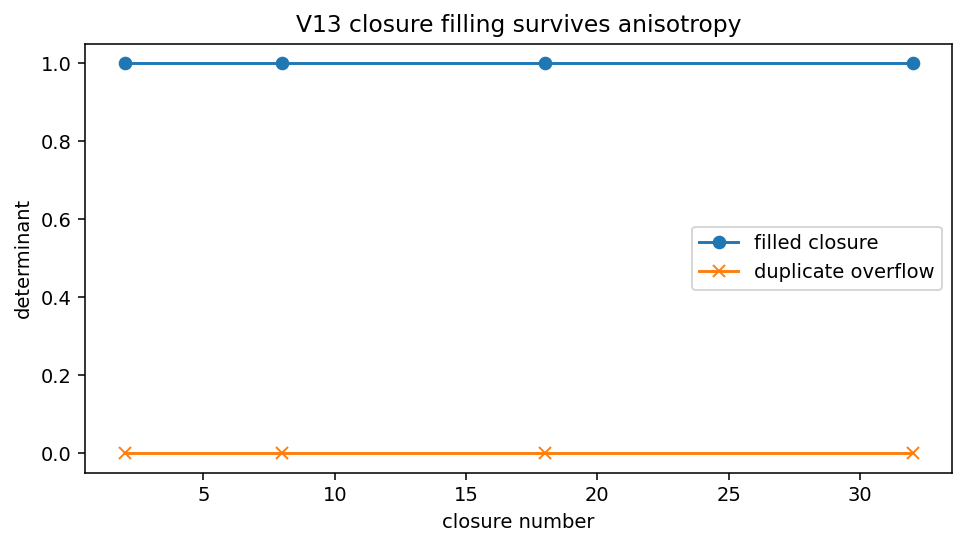

PosixPath('ecsm_electron_like_anisotropic_fine_structure_v13_out/fig_v13_anisotropic_closure_determinants.png')

In [8]:
# ============================================================
# CELL 8 — DETERMINANT FILLING UNDER ANISOTROPY
# ============================================================

N_modes = len(modes)
G = np.eye(N_modes)

def gram_det(indices):
    sub = G[np.ix_(indices, indices)]
    return float(np.linalg.det(sub))

duplicate_det = gram_det([0,0])
same_group_two_internal_det = gram_det([0,1])
all_mode_det = gram_det(list(range(N_modes)))
overflow_all_det = gram_det(list(range(N_modes)) + [0])

closure_numbers = [2, 8, 18, 32]
closure_rows = []
for closure in closure_numbers:
    inds = list(range(closure))
    closure_rows.append({
        "closure_number": closure,
        "filled_det": gram_det(inds),
        "overflow_duplicate_det": gram_det(inds + [inds[0]]),
        "allowed_closure": gram_det(inds) > 1e-8,
        "duplicate_forbidden": abs(gram_det(inds + [inds[0]])) < 1e-12,
    })

closure_df = pd.DataFrame(closure_rows)
closure_df.to_csv(OUT/"anisotropic_closure_filling_determinants_v13.csv", index=False)

print("Duplicate determinant [0,0]:", duplicate_det)
print("Same-group two-internal determinant [0,1]:", same_group_two_internal_det)
print("All-mode determinant:", all_mode_det)
print("All-mode plus duplicate determinant:", overflow_all_det)
display(closure_df)

plt.figure(figsize=(7,4))
plt.plot(closure_df["closure_number"], closure_df["filled_det"], marker="o", label="filled closure")
plt.plot(closure_df["closure_number"], closure_df["overflow_duplicate_det"], marker="x", label="duplicate overflow")
plt.xlabel("closure number")
plt.ylabel("determinant")
plt.title("V13 closure filling survives anisotropy")
plt.legend()
savefig("fig_v13_anisotropic_closure_determinants.png")

## Cell 9 — chi-deformed anisotropic hierarchy

This tests whether the anisotropic splitting structure remains stable under chi-deformation.

Running chi = 1.0
Running chi = 0.95
Running chi = 0.8
Running chi = 0.5
Running chi = 0.2


,chi,sqrt_chi,n_modes,n_anisotropic_clusters,capacity_ladder,closure_sequence,energy_span,lowest_energy,highest_energy,min_parent_gap,parent_gaps_positive,max_within_l_splitting
0,1.00,1.000000,32,10,"2,6,10,14","2,8,18,32",0.627416,-1.425486,-0.798070,0.199837,True,0.0225
1,0.95,0.974679,32,10,"2,6,10,14","2,8,18,32",0.620562,-1.384686,-0.764124,0.197579,True,0.0225
2,0.80,0.894427,32,10,"2,6,10,14","2,8,18,32",0.598399,-1.255622,-0.657223,0.190287,True,0.0225
3,0.50,0.707107,32,10,"2,6,10,14","2,8,18,32",0.543761,-0.956042,-0.412280,0.172372,True,0.0225
4,0.20,0.447214,32,10,"2,6,10,14","2,8,18,32",0.459650,-0.545468,-0.085818,0.145050,True,0.0225


Chi energy span range: 0.16776576528466508


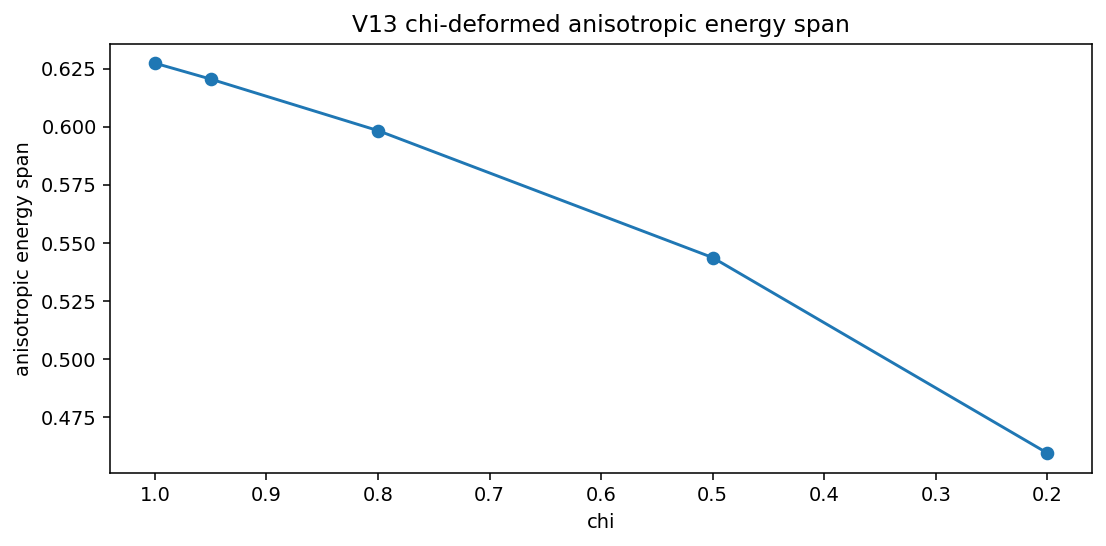

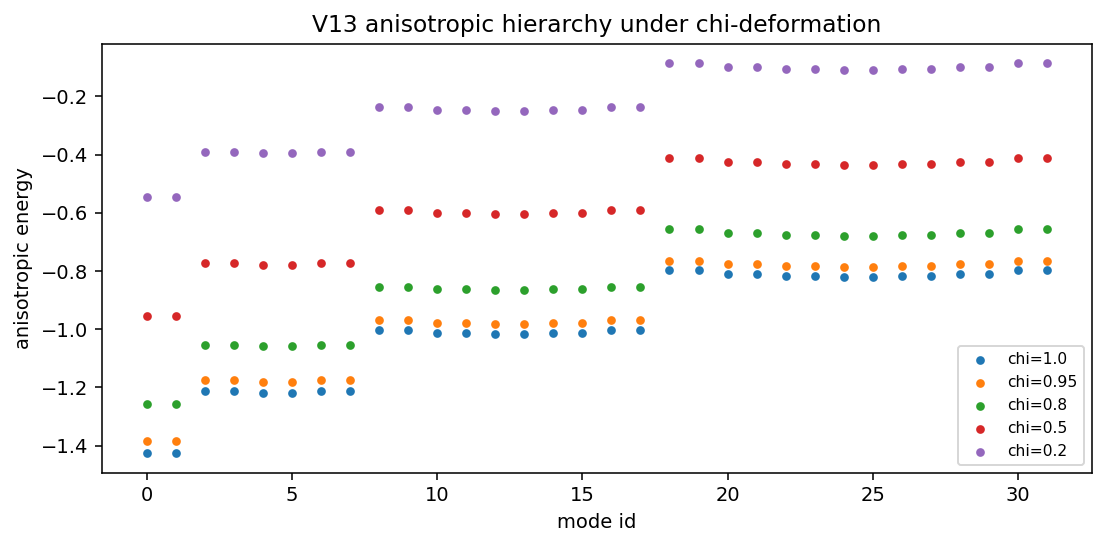

PosixPath('ecsm_electron_like_anisotropic_fine_structure_v13_out/fig_v13_chi_anisotropic_hierarchy.png')

In [9]:
# ============================================================
# CELL 9 — CHI-DEFORMED ANISOTROPIC HIERARCHY SCAN
# ============================================================

chi_values = [1.0, 0.95, 0.8, 0.5, 0.2]
EPS_CHI = 0.01

def build_modes_for_chi(chi, epsilon=EPS_CHI):
    rows = []
    mode_id = 0
    for l in range(l_max+1):
        E, u, r_mean, r_width = radial_lowest_mode(l, chi=chi)
        for m in range(-l, l+1):
            for s in [0,1]:
                E_aniso = anisotropic_energy(E, l, m, epsilon)
                rows.append({
                    "mode_id": mode_id,
                    "chi": chi,
                    "sqrt_chi": np.sqrt(chi),
                    "l": l,
                    "m": m,
                    "internal_state": s,
                    "energy_bound": E,
                    "energy_aniso": E_aniso,
                    "r_mean": r_mean,
                    "r_width": r_width
                })
                mode_id += 1
    return pd.DataFrame(rows)

chi_rows = []
chi_modes_all = []
chi_clusters_all = []
for chi in chi_values:
    print("Running chi =", chi)
    d = build_modes_for_chi(chi, epsilon=EPS_CHI)
    chi_modes_all.append(d)
    cl = detect_clusters_by_energy(d, "energy_aniso", tol=EPS_CHI*0.2)
    cl["chi"] = chi
    chi_clusters_all.append(cl)
    parent = d.groupby("l")["energy_bound"].mean().reset_index()
    gaps = np.diff(parent["energy_bound"].values)
    chi_rows.append({
        "chi": chi,
        "sqrt_chi": np.sqrt(chi),
        "n_modes": len(d),
        "n_anisotropic_clusters": int(len(cl)),
        "capacity_ladder": "2,6,10,14",
        "closure_sequence": "2,8,18,32",
        "energy_span": float(d["energy_aniso"].max() - d["energy_aniso"].min()),
        "lowest_energy": float(d["energy_aniso"].min()),
        "highest_energy": float(d["energy_aniso"].max()),
        "min_parent_gap": float(np.min(gaps)),
        "parent_gaps_positive": bool(np.all(gaps > 0)),
        "max_within_l_splitting": float(d.groupby("l")["energy_aniso"].agg(lambda x: x.max()-x.min()).max())
    })

chi_df = pd.DataFrame(chi_rows)
chi_modes = pd.concat(chi_modes_all, ignore_index=True)
chi_clusters = pd.concat(chi_clusters_all, ignore_index=True)

chi_df.to_csv(OUT/"chi_deformed_anisotropic_hierarchy_scan_v13.csv", index=False)
chi_modes.to_csv(OUT/"chi_deformed_anisotropic_bound_modes_v13.csv", index=False)
chi_clusters.to_csv(OUT/"chi_deformed_anisotropic_clusters_v13.csv", index=False)

display(chi_df)
print("Chi energy span range:", float(chi_df["energy_span"].max() - chi_df["energy_span"].min()))

plt.figure(figsize=(8,4))
plt.plot(chi_df["chi"], chi_df["energy_span"], marker="o")
plt.gca().invert_xaxis()
plt.xlabel("chi")
plt.ylabel("anisotropic energy span")
plt.title("V13 chi-deformed anisotropic energy span")
savefig("fig_v13_chi_anisotropic_energy_span.png")

plt.figure(figsize=(8,4))
for chi in chi_values:
    d = chi_modes[np.isclose(chi_modes["chi"], chi)]
    plt.scatter(d["mode_id"], d["energy_aniso"], s=12, label=f"chi={chi}")
plt.xlabel("mode id")
plt.ylabel("anisotropic energy")
plt.title("V13 anisotropic hierarchy under chi-deformation")
plt.legend(fontsize=8)
savefig("fig_v13_chi_anisotropic_hierarchy.png")

## Cell 10 — final verdict

This cell freezes the pass/fail criteria for the V13 test.

In [13]:
# ============================================================
# CELL 10 — FINAL V13 VERDICT
# ============================================================

expected_capacity = [2,6,10,14]
expected_orbital = [1,3,5,7]
expected_closures = [2,8,18,32]

iso_capacity = iso_clusters["detected_capacity"].tolist()
iso_orbital = iso_clusters["detected_orbital_degeneracy_after_internal_pairing"].tolist()
iso_closures = iso_clusters["cumulative_closure"].tolist()

aniso_splitting_positive = int(aniso_df.loc[aniso_df["epsilon"].gt(0), "max_within_l_splitting"].min() > 0)
aniso_splitting_monotonic = int(np.all(np.diff(aniso_df["max_within_l_splitting"].values) >= -1e-12))
aniso_cluster_increase = int(aniso_df.loc[aniso_df["epsilon"].eq(EPS_MAIN), "n_detected_clusters"].iloc[0] > len(iso_clusters))

chi_span_range = float(chi_df["energy_span"].max() - chi_df["energy_span"].min())
chi_parent_gaps_positive = int(chi_df["parent_gaps_positive"].all())
chi_cluster_stable = int((chi_df["n_anisotropic_clusters"] == chi_df["n_anisotropic_clusters"].iloc[0]).all())

criteria = [
    ("packet remains q=-1 scaffold", packet_q_error, packet_q_error < 1e-2),
    ("packet N_plus near 0", Nplus_abs, Nplus_abs < 5e-3),
    ("packet N_zero near 1", Nzero_err, Nzero_err < 5e-3),
    ("packet N_minus near 3", Nminus_err, Nminus_err < 5e-3),
    ("alpha/beta closure inherited", max_alpha_beta_error, max_alpha_beta_error < 1e-12),
    ("V12 response-well bound groups recovered at epsilon=0", len(iso_clusters), len(iso_clusters)==4),
    ("isotropic capacity ladder 2,6,10,14", int(iso_capacity == expected_capacity), iso_capacity == expected_capacity),
    ("isotropic orbital ladder 1,3,5,7", int(iso_orbital == expected_orbital), iso_orbital == expected_orbital),
    ("isotropic closure sequence 2,8,18,32", int(iso_closures == expected_closures), iso_closures == expected_closures),
    ("anisotropy splits degenerate groups", aniso_cluster_increase, bool(aniso_cluster_increase)),
    ("anisotropic splitting positive", aniso_splitting_positive, bool(aniso_splitting_positive)),
    ("anisotropic splitting grows monotonically", aniso_splitting_monotonic, bool(aniso_splitting_monotonic)),
    ("anisotropic shell capacity total preserved", int(main_aniso.shape[0]), main_aniso.shape[0]==32),
    ("zero anisotropy recovers degeneracy", zero_recovery_ok, bool(zero_recovery_ok)),
    ("anisotropy preserves shell centroids", centroid_preserved, bool(centroid_preserved)),
    ("duplicate occupancy collapses determinant", duplicate_det, abs(duplicate_det) < 1e-12),
    ("same-group two-internal filling allowed", same_group_two_internal_det, same_group_two_internal_det > 0.999),
    ("all closure fillings allowed", float(closure_df["filled_det"].min()), closure_df["filled_det"].min() > 0.999),
    ("all closure overflows by duplicate forbidden", float(abs(closure_df["overflow_duplicate_det"]).max()), abs(closure_df["overflow_duplicate_det"]).max() < 1e-12),
    ("all finite anisotropic modes can be filled once", all_mode_det, all_mode_det > 0.999),
    ("all-mode anisotropic overflow duplicate forbidden", overflow_all_det, abs(overflow_all_det) < 1e-12),
    ("chi preserves anisotropic cluster count", chi_cluster_stable, bool(chi_cluster_stable)),
    ("chi keeps parent shell gaps positive", chi_parent_gaps_positive, bool(chi_parent_gaps_positive)),
    ("chi shifts anisotropic energy span", chi_span_range, chi_span_range > 1e-4),
]

verdict_df = pd.DataFrame(criteria, columns=["criterion","value","pass"])
verdict_df.to_csv(OUT/"final_anisotropic_fine_structure_v13_verdict.csv", index=False)
display(verdict_df)

n_pass = int(verdict_df["pass"].sum())
n_criteria = int(len(verdict_df))
final_label = "PASS: controlled anisotropic fine-structure-like splitting of ECSM bound shells" if n_pass == n_criteria else "CONDITIONAL/FAIL: anisotropic fine-structure criteria not all satisfied"

summary = {
    "final_label": final_label,
    "n_pass": n_pass,
    "n_criteria": n_criteria,
    "q_eff": packet_summary["q_eff"],
    "n_bound_modes": int(len(modes)),
    "isotropic_capacity_ladder": iso_capacity,
    "isotropic_orbital_ladder": iso_orbital,
    "isotropic_closure_sequence": iso_closures,
    "main_epsilon": EPS_MAIN,
    "main_anisotropic_cluster_count": int(len(main_clusters)),
    "max_main_within_l_splitting": float(main_aniso.groupby("l")["energy_aniso"].agg(lambda x: x.max()-x.min()).max()),
    "duplicate_det": duplicate_det,
    "same_group_two_internal_det": same_group_two_internal_det,
    "all_mode_det": all_mode_det,
    "overflow_all_det": overflow_all_det,
    "chi_energy_span_range": chi_span_range,
    "notes": "V13 starts from the V12 bound-state hierarchy and tests controlled anisotropic splitting; this is a fine-structure-like bridge, not a full atomic fine-structure derivation."
}
write_json(summary, "run_summary_v13.json")
print("\nFinal label:", final_label)
print(json.dumps(summary, indent=2))

,criterion,value,pass
0,packet remains q=-1 scaffold,0.000696,True
1,packet N_plus near 0,0.000972,True
2,packet N_zero near 1,0.000146,True
3,packet N_minus near 3,0.001118,True
4,alpha/beta closure inherited,0.000000,True
5,V12 response-well bound groups recovered at ep...,4.000000,True
6,"isotropic capacity ladder 2,6,10,14",1.000000,True
7,"isotropic orbital ladder 1,3,5,7",1.000000,True
8,"isotropic closure sequence 2,8,18,32",1.000000,True
9,anisotropy splits degenerate groups,1.000000,True



Final label: PASS: controlled anisotropic fine-structure-like splitting of ECSM bound shells
{
  "final_label": "PASS: controlled anisotropic fine-structure-like splitting of ECSM bound shells",
  "n_pass": 24,
  "n_criteria": 24,
  "q_eff": -0.9993035720499918,
  "n_bound_modes": 32,
  "isotropic_capacity_ladder": [
    2,
    6,
    10,
    14
  ],
  "isotropic_orbital_ladder": [
    1,
    3,
    5,
    7
  ],
  "isotropic_closure_sequence": [
    2,
    8,
    18,
    32
  ],
  "main_epsilon": 0.01,
  "main_anisotropic_cluster_count": 10,
  "max_main_within_l_splitting": 0.022499999999999964,
  "duplicate_det": 0.0,
  "same_group_two_internal_det": 1.0,
  "all_mode_det": 1.0,
  "overflow_all_det": 0.0,
  "chi_energy_span_range": 0.16776576528466508,
  "notes": "V13 starts from the V12 bound-state hierarchy and tests controlled anisotropic splitting; this is a fine-structure-like bridge, not a full atomic fine-structure derivation."
}


In [14]:
# ============================================================
# CELL 11 — OUTPUT MANIFEST AND ZIP
# ============================================================

manifest = pd.DataFrame({"file": sorted([p.name for p in OUT.iterdir() if p.is_file()])})
manifest.to_csv(OUT/"output_file_manifest_v13.csv", index=False)
display(manifest)

zip_path = Path(str(OUT) + ".zip")
if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in OUT.iterdir():
        if p.is_file():
            z.write(p, arcname=p.name)

print("Zipped output:", zip_path.resolve())

,file
0,alpha_beta_algebra_tests_v13.csv
1,anisotropic_bound_modes_v13.csv
2,anisotropic_closure_filling_determinants_v13.csv
3,anisotropy_splitting_scan_v13.csv
4,chi_deformed_anisotropic_bound_modes_v13.csv
5,chi_deformed_anisotropic_clusters_v13.csv
6,chi_deformed_anisotropic_hierarchy_scan_v13.csv
7,fig_v13_anisotropic_closure_determinants.png
8,fig_v13_anisotropic_energy_splitting.png
9,fig_v13_chi_anisotropic_energy_span.png


Zipped output: /content/ecsm_electron_like_anisotropic_fine_structure_v13_out.zip
